<a href="https://colab.research.google.com/github/dhruvi013/AI/blob/main/Reinforcement_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import networkx as nx
import pylab as pl

In [ ]:
#define the graph
edges=[(0,1),(1,2),(1,3),(1,5),(5,6),(5,4),(9,10),(2,4),(0,6),(6,7),(8,9),(7,8),(1,7),(3,9),(10,8),(10,10),]

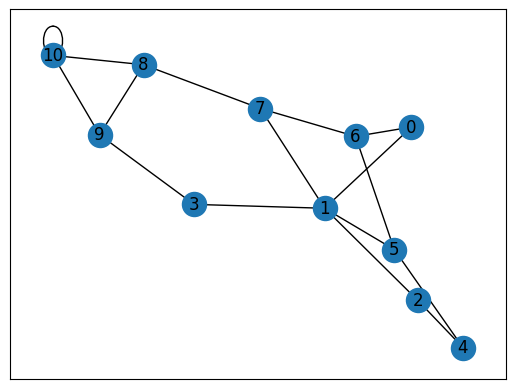

In [ ]:
G=nx.Graph()
G.add_edges_from(edges)
pos=nx.spring_layout(G)
nx.draw_networkx_nodes(G,pos)
nx.draw_networkx_edges(G,pos)
nx.draw_networkx_labels(G,pos)
pl.show()

In [ ]:
Matrix_size=11
goal=10
#Reward matrix
R=np.matrix(np.ones((Matrix_size,Matrix_size)))
R*=-1

In [ ]:
R

matrix([[-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.]])

In [ ]:
for edge in edges:
  if(edge[1]==goal):
    R[edge]=100
  else:
    R[edge]=0
  if(edge[0]==goal):
    R[edge[::-1]]=100
  else:
    R[edge[::-1]]=0
R[goal,goal]=100
print(R)

[[ -1.   0.  -1.  -1.  -1.  -1.   0.  -1.  -1.  -1.  -1.]
 [  0.  -1.   0.   0.  -1.   0.  -1.   0.  -1.  -1.  -1.]
 [ -1.   0.  -1.  -1.   0.  -1.  -1.  -1.  -1.  -1.  -1.]
 [ -1.   0.  -1.  -1.  -1.  -1.  -1.  -1.  -1.   0.  -1.]
 [ -1.  -1.   0.  -1.  -1.   0.  -1.  -1.  -1.  -1.  -1.]
 [ -1.   0.  -1.  -1.   0.  -1.   0.  -1.  -1.  -1.  -1.]
 [  0.  -1.  -1.  -1.  -1.   0.  -1.   0.  -1.  -1.  -1.]
 [ -1.   0.  -1.  -1.  -1.  -1.   0.  -1.   0.  -1.  -1.]
 [ -1.  -1.  -1.  -1.  -1.  -1.  -1.   0.  -1.   0. 100.]
 [ -1.  -1.  -1.   0.  -1.  -1.  -1.  -1.   0.  -1. 100.]
 [ -1.  -1.  -1.  -1.  -1.  -1.  -1.  -1.   0.   0. 100.]]


In [ ]:
Q=R=np.matrix(np.zeros((Matrix_size,Matrix_size)))

In [ ]:
initial_state=1  #random

In [ ]:
def available_states(state):
  current_row=R[state,]
  available_options=np.where(current_row>-1)[1]
  return available_options

In [ ]:
int(np.random.choice([1,2,3,4],1))

<ipython-input-15-2d5e2aee1cbe>:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(np.random.choice([1,2,3,4],1))


4

In [ ]:
def next_state_selection(available_options):
  return(int(np.random.choice(available_options,1)))

In [ ]:
def Q_update_Value(current_State,action,gamma):
  max_index=np.where(Q[action]==np.max(Q[action,]))[1]
  if(max_index.shape[0]>1):
    max_index=int(np.random.choice(max_index,1))
  else:
    max_index=int(max_index)
  max_value=Q[action,max_index]
  Q[current_State,action]=R[current_State,action]+gamma*max_value
  if(np.max(Q)>0):
    return(np.sum(Q/np.max(Q)*100))
  else:
    return(0)

In [ ]:
#Training the model
score=[]
gamma=0.75
for i in range(1000):
  current_State=np.random.randint(0,int(Q.shape[0]))
  available_paths=available_states(current_State)
  next_state=next_state_selection(available_paths)
  scores=Q_update_Value=(current_State,next_state,gamma)
  score.append(scores)

<ipython-input-16-7c2dc8519d2f>:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return(int(np.random.choice(available_options,1)))


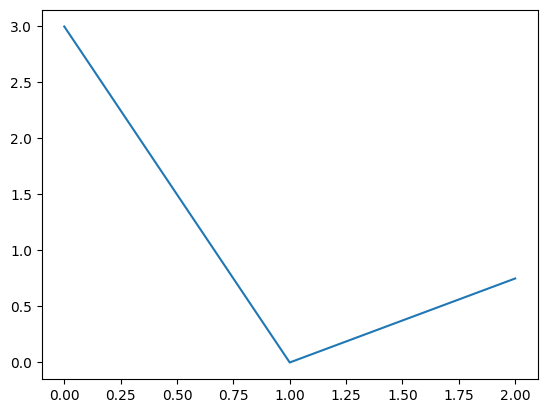

In [ ]:
pl.plot(scores)

In [ ]:
currect_State=2
steps=[current_State]
while(current_State!=goal):
  max_index=np.where(Q[current_State]==np.max(Q[current_State,]))[1]
  if(max_index.shape[0]>1):
    max_index=int(np.random.choice(max_index,1))
  else:
    max_index=int(max_index)
  steps.append(max_index)
  current_State=max_index
steps

<ipython-input-26-eb600b84ce34>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_index=int(np.random.choice(max_index,1))


[3, 6, 0, 9, 9, 1, 8, 1, 10]